In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

File: data/SouthGermanCredit.asc
Shape: (1000, 21)
Clusters(best_k): 6
PCA components (70%): 11
Silhouette full: 0.0864
Silhouette pca:  0.0810
DB full: 2.3882
DB pca:  2.3959
ARI(full vs pca labels): 0.3758


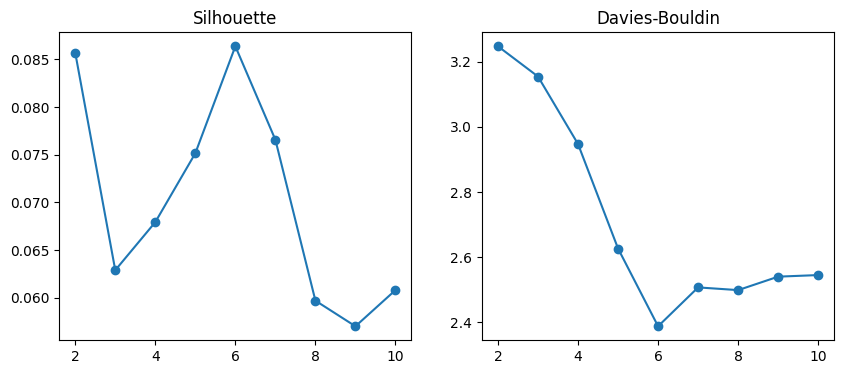

In [2]:


candidates = [
    "data/SouthGermanCredit.asc",
]

path = next((p for p in candidates if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(f"Data file not found. CWD={os.getcwd()}")

df = pd.read_table(path, header=0, sep=r"\s+", engine="python")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

target = "kredit" if "kredit" in df.columns else "credit_risk"
X = df.drop(columns=[target]).to_numpy()

X_st = StandardScaler().fit_transform(X)

K = list(range(2, 11))
sil_vals, db_vals = [], []

for k in K:
    lab = MiniBatchKMeans(n_clusters=k, batch_size=256, n_init=10, random_state=42).fit_predict(X_st)
    sil_vals.append(silhouette_score(X_st, lab))
    db_vals.append(davies_bouldin_score(X_st, lab))

best_k = K[int(np.argmax(sil_vals))]

pca_full = PCA().fit(X_st)
variance = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(variance >= 0.7) + 1)

X_pca = PCA(n_components=n_comp, random_state=42).fit_transform(X_st)

full_labels = MiniBatchKMeans(n_clusters=best_k, batch_size=256, n_init=10, random_state=42).fit_predict(X_st)
pca_labels = MiniBatchKMeans(n_clusters=best_k, batch_size=256, n_init=10, random_state=42).fit_predict(X_pca)

print(f"File: {path}")
print(f"Shape: {df.shape}")
print(f"Clusters(best_k): {best_k}")
print(f"PCA components (70%): {n_comp}")
print(f"Silhouette full: {silhouette_score(X_st, full_labels):.4f}")
print(f"Silhouette pca:  {silhouette_score(X_pca, pca_labels):.4f}")
print(f"DB full: {davies_bouldin_score(X_st, full_labels):.4f}")
print(f"DB pca:  {davies_bouldin_score(X_pca, pca_labels):.4f}")
print(f"ARI(full vs pca labels): {adjusted_rand_score(full_labels, pca_labels):.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K, sil_vals, "o-")
plt.title("Silhouette")
plt.subplot(1, 2, 2)
plt.plot(K, db_vals, "o-")
plt.title("Davies-Bouldin")
plt.show()